In [3]:
import numpy as np
from matplotlib import pyplot as plt

## 準備資料點和線性模型

In [4]:
def create_linear_samples(w=-1.0, b=3.0, n_samples=100):
  x_max = 3
  x_min = -3
  sigma = 0.5
  xs = np.random.uniform(x_min, x_max, n_samples)
  ys = w * xs + b + np.random.normal(0.0, sigma, n_samples)
  return xs, ys


In [5]:
def get_line(w, b):
  x_max = 3
  x_min = -3
  y_max = w * x_max + b
  y_min = w * x_min + b
  return [x_min, x_max], [y_min, y_max]

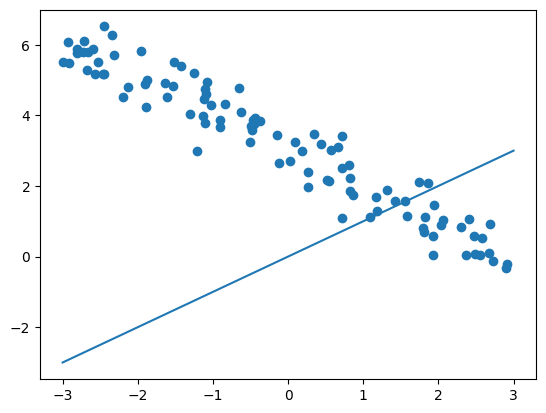

In [6]:
w = 1.0
b = 0.0
xs, ys = create_linear_samples()
xl, yl = get_line(w, b)
plt.scatter(xs, ys)
plt.plot(xl, yl)
plt.show()

## Q: 要怎麼調整參數?

我們需要定義一個目前表現「有多好」的評分方式。最常見的就是mean squared error (MSE)

In [7]:
def linear_mse(xs, ys, w, b):
  sum = 0
  for i in range(len(xs)):
    sum += (ys[i] - w * xs[i] - b) ** 2
  return sum / len(xs)

In [8]:
loss_base = linear_mse(xs, ys, w, b)
loss_base

np.float64(24.93046872691135)

接下來，因為我們的目標是調整w,b到最佳解，所以我們試探性地分別調整w和b，看看是變好還變壞


In [9]:
delta = 0.1

In [10]:
loss_base = linear_mse(xs, ys, w, b)
loss_dw = linear_mse(xs, ys, w+delta, b)
loss_db = linear_mse(xs, ys, w, b+delta)

In [11]:
grad_w = (loss_dw - loss_base) / delta
grad_b = (loss_db - loss_base) / delta
print(grad_w, grad_b)
#grad_w、grad_b 要越趨於0，因此:
# w 太陡了，往下修一點；(正太多)
# b 太低了，往上抬一點。(負太多)

14.30322157723026 -6.72258995958142


計算完梯度後，開始往梯度反方向走: 梯度下降法

需要注意步伐不能太大，要將梯度值縮小再調w,b

In [12]:
lr = 0.03 # 設定學習率learning_rate (lr)

In [13]:
w2 = w - grad_w * lr
b2 = b - grad_b * lr
print(w2, b2)

0.5709033526830922 0.2016776987874426


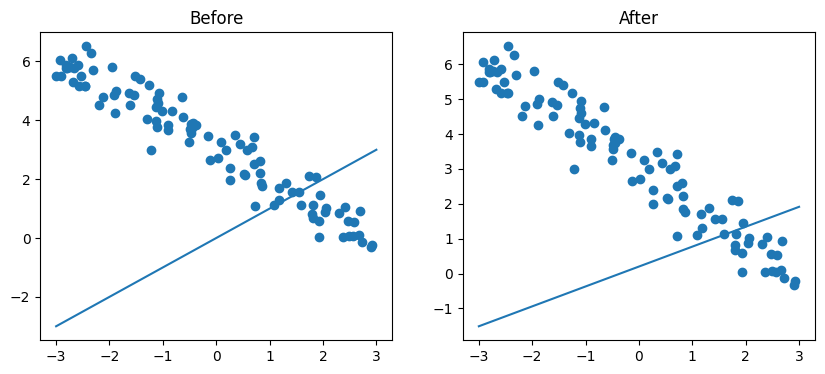

In [14]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(xs, ys)
plt.plot(xl, yl)
plt.title('Before')

x2, y2 = get_line(w2, b2)
plt.subplot(1,2,2)
plt.scatter(xs, ys)
plt.plot(x2, y2)
plt.title('After')

plt.show()

## 將梯度下降包裝成函數

In [15]:
def gradient_descend_once(xs, ys, w, b):
  delta = 1e-5 # 試探用的步伐大小，可以盡量小
  lr = 0.03 # 設定學習率learning_rate (lr)
  # 先計算踩步的損失
  loss_base = linear_mse(xs, ys, w, b)
  loss_dw = linear_mse(xs, ys, w+delta, b)
  loss_db = linear_mse(xs, ys, w, b+delta)
  # 計算損失的梯度
  grad_w = (loss_dw - loss_base) / delta
  grad_b = (loss_db - loss_base) / delta
  # 依據學習率與梯度更新w,b
  w2 = w - grad_w * lr
  b2 = b - grad_b * lr
  return w2, b2

In [16]:
# 複製一份避免動到原版的w,b
_w = w
_b = b

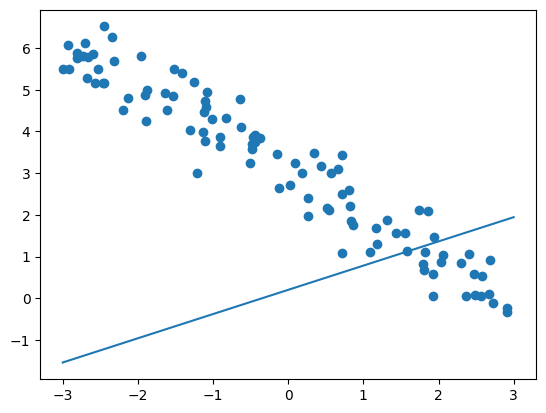

In [17]:
# 重複執行這一格，可以看到直線逐漸對齊資料點
_w, _b = gradient_descend_once(xs, ys, _w, _b)
x_once, y_once = get_line(_w, _b)
plt.scatter(xs, ys)
plt.plot(x_once, y_once)
plt.show()

In [18]:
def gradient_descend(xs, ys, w, b, n_steps=100):
  _w = w
  _b = b
  for _ in range(n_steps):
    _w, _b = gradient_descend_once(xs, ys, _w, _b)
  return _w, _b

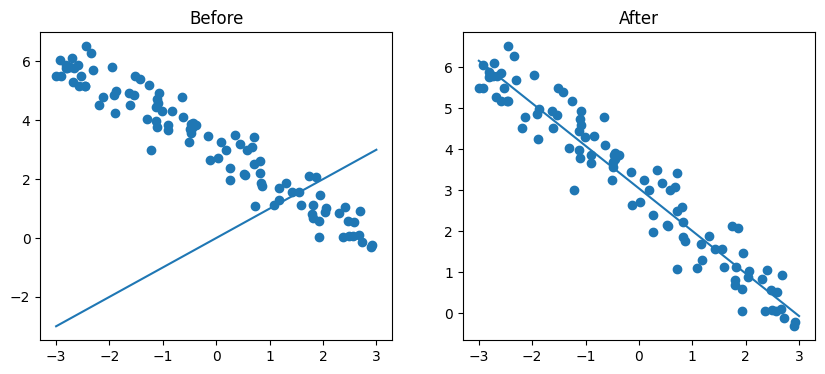

In [19]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(xs, ys)
plt.plot(xl, yl)
plt.title('Before')

w3, b3 = gradient_descend(xs, ys, w, b)
x3, y3 = get_line(w3, b3)
plt.subplot(1,2,2)
plt.scatter(xs, ys)
plt.plot(x3, y3)
plt.title('After')

plt.show()